# Segmentación de clientes de Starbucks

Este notebook reorganiza el análisis original bajo un proceso de KDD (Knowledge Discovery in Databases) y construye una tabla analítica por cliente para estudiar segmentos de comportamiento.

El flujo incluye: comprensión de datos, preparación, ingeniería de variables, reducción de dimensionalidad con PCA, análisis factorial, clustering jerárquico, K-Means y *soft clustering* con Gaussian Mixture Models (GMM).

## Estructura del proceso KDD

1. **Selección y comprensión de los datos**: carga y revisión inicial de `portfolio`, `profile` y `transcript`.
2. **Limpieza y transformación**: normalización de eventos, imputación de valores faltantes y construcción de variables por cliente.
3. **Reducción de dimensionalidad**: PCA para compresión y análisis factorial para interpretación latente.
4. **Minería de datos**: clustering jerárquico, K-Means y GMM.
5. **Interpretación y evaluación**: comparación de métricas y perfilado de segmentos.

In [70]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import FactorAnalysis, PCA
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from IPython.display import Markdown, display

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11

In [71]:
RUTA_BASE = Path('.')
RUTA_DATOS = RUTA_BASE / 'data'
SEMILLA = 42
RANGO_K = range(2, 15)

def resumen_tabla(df, nombre):
    return pd.DataFrame({
        'tabla': [nombre],
        'filas': [df.shape[0]],
        'columnas': [df.shape[1]],
        'nulos_totales': [int(df.isna().sum().sum())]
    })

def construir_tabla_clientes(portfolio, profile, transcript):
    profile = profile.rename(columns={'id': 'person'}).copy()
    profile['became_member_on'] = pd.to_datetime(profile['became_member_on'], format='%Y%m%d')
    profile['age'] = profile['age'].replace(118, np.nan)

    clientes_validos = profile[['person', 'age', 'income', 'gender']].notna().all(axis=1)
    profile_model = profile.loc[clientes_validos].copy()

    ventana_analisis_dias = int(np.ceil(transcript['time'].max() / 24))
    fecha_corte = profile_model['became_member_on'].max() + pd.Timedelta(days=ventana_analisis_dias)

    profile_model['membership_days'] = (fecha_corte - profile_model['became_member_on']).dt.days
    profile_model['membership_year'] = profile_model['became_member_on'].dt.year
    profile_model['membership_month'] = profile_model['became_member_on'].dt.month
    profile_model = pd.get_dummies(
        profile_model.drop(columns=['became_member_on']),
        columns=['gender'],
        prefix='gender',
        dtype=int
    )

    personas_modelo = set(profile_model['person'])

    transcript_model = transcript[transcript['person'].isin(personas_modelo)].copy()
    transcript_model['offer_id'] = transcript_model['value'].apply(lambda x: x.get('offer id') or x.get('offer_id'))
    transcript_model['amount'] = transcript_model['value'].apply(lambda x: x.get('amount', 0.0))
    transcript_model['reward_value'] = transcript_model['value'].apply(lambda x: x.get('reward', 0.0))
    transcript_model['time_days'] = transcript_model['time'] / 24

    portfolio = portfolio.rename(columns={'id': 'offer_id'}).copy()
    portfolio['offer_type_raw'] = portfolio['offer_type']
    for canal in ['web', 'email', 'mobile', 'social']:
        portfolio[f'channel_{canal}'] = portfolio['channels'].apply(lambda xs, c=canal: int(c in xs))

    portfolio_model = pd.get_dummies(
        portfolio,
        columns=['offer_type'],
        prefix='offer',
        dtype=int
    )

    offer_events = transcript_model[transcript_model['offer_id'].notna()].merge(
        portfolio_model.drop(columns=['channels']),
        on='offer_id',
        how='left'
    )

    transactions = transcript_model[transcript_model['event'].eq('transaction')].copy()

    transaction_features = transactions.groupby('person').agg(
        txn_count=('amount', 'size'),
        txn_amount_sum=('amount', 'sum'),
        txn_amount_mean=('amount', 'mean'),
        txn_amount_max=('amount', 'max'),
        txn_amount_std=('amount', 'std'),
        txn_first_day=('time_days', 'min'),
        txn_last_day=('time_days', 'max')
    )
    transaction_features['txn_amount_std'] = transaction_features['txn_amount_std'].fillna(0)
    transaction_features['txn_active_span_days'] = transaction_features['txn_last_day'] - transaction_features['txn_first_day']
    transaction_features['txn_amount_per_day'] = transaction_features['txn_amount_sum'] / transaction_features['txn_last_day'].replace(0, np.nan)
    transaction_features['txn_amount_per_day'] = transaction_features['txn_amount_per_day'].replace([np.inf, -np.inf], np.nan).fillna(0)

    event_counts = transcript_model.pivot_table(
        index='person',
        columns='event',
        values='time',
        aggfunc='count',
        fill_value=0
    )
    event_counts.columns = [f"event_{col.replace(' ', '_')}_count" for col in event_counts.columns]

    offer_type_counts = offer_events.pivot_table(
        index='person',
        columns='offer_type_raw',
        values='event',
        aggfunc='count',
        fill_value=0
    )
    offer_type_counts.columns = [f'offer_interactions_{col}' for col in offer_type_counts.columns]

    event_offer_counts = offer_events.pivot_table(
        index='person',
        columns=['event', 'offer_type_raw'],
        values='time',
        aggfunc='count',
        fill_value=0
    )
    event_offer_counts.columns = [
        f"{evento.replace(' ', '_')}_{tipo}"
        for evento, tipo in event_offer_counts.columns
    ]

    channel_exposure = offer_events.groupby('person')[
        [col for col in offer_events.columns if col.startswith('channel_')]
    ].sum()

    offer_stats = offer_events.groupby('person').agg(
        offer_reward_mean=('reward', 'mean'),
        offer_difficulty_mean=('difficulty', 'mean'),
        offer_duration_mean=('duration', 'mean')
    )

    customer_features = (
        profile_model.set_index('person')
        .join(transaction_features)
        .join(event_counts)
        .join(offer_type_counts)
        .join(event_offer_counts)
        .join(channel_exposure)
        .join(offer_stats)
        .fillna(0)
        .sort_index()
    )

    for tipo in ['bogo', 'discount', 'informational']:
        recibidas = customer_features.get(f'offer_received_{tipo}')
        vistas = customer_features.get(f'offer_viewed_{tipo}')
        completadas = customer_features.get(f'offer_completed_{tipo}')

        if recibidas is None or vistas is None:
            continue

        tasa_vista = np.where(recibidas > 0, vistas / recibidas, 0.0)
        customer_features[f'view_rate_{tipo}'] = np.clip(tasa_vista, 0, 1)

        if tipo != 'informational' and completadas is not None:
            tasa_conversion = np.where(vistas > 0, completadas / vistas, 0.0)
            customer_features[f'completion_rate_{tipo}'] = np.clip(tasa_conversion, 0, 1)

    return profile_model, transcript_model, portfolio_model, offer_events, transactions, customer_features

def calcular_metricas(X, labels):
    return {
        'silhouette': silhouette_score(X, labels),
        'calinski_harabasz': calinski_harabasz_score(X, labels),
        'davies_bouldin': davies_bouldin_score(X, labels)
    }

def resumen_segmentos(df_features, labels, top_n=12):
    z = pd.DataFrame(
        StandardScaler().fit_transform(df_features),
        index=df_features.index,
        columns=df_features.columns
    )
    z['segmento'] = labels
    medias = z.groupby('segmento').mean()
    variables_top = medias.std(axis=0).sort_values(ascending=False).head(top_n).index
    return medias[variables_top].T

def graficar_clusters_pca(X_pca_df, labels, titulo):
    df_plot = X_pca_df.iloc[:, :2].copy()
    df_plot.columns = ['PC1', 'PC2']
    df_plot['segmento'] = labels

    plt.figure(figsize=(9, 6))
    sns.scatterplot(data=df_plot, x='PC1', y='PC2', hue='segmento', palette='tab10', s=28, alpha=0.7)
    plt.title(titulo)
    plt.legend(title='Segmento', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()

## 1. Selección y comprensión de los datos

Cargamos las tres fuentes originales y revisamos su tamaño, estructura y nivel de datos faltantes.

In [72]:
portfolio = pd.read_json(RUTA_DATOS / 'portfolio.json', orient='records', lines=True)
profile = pd.read_json(RUTA_DATOS / 'profile.json', orient='records', lines=True)
transcript = pd.read_json(RUTA_DATOS / 'transcript.json', orient='records', lines=True)

display(pd.concat([
    resumen_tabla(portfolio, 'portfolio'),
    resumen_tabla(profile, 'profile'),
    resumen_tabla(transcript, 'transcript')
]))

display(portfolio.head())
display(profile.head())
display(transcript.head())

,tabla,filas,columnas,nulos_totales
0,portfolio,10,6,0
0,profile,17000,5,4350
0,transcript,306534,4,0


,reward,channels,difficulty,duration,offer_type,id
0,10,"[email, mobile, social]",10,7,bogo,ae264e3637204a6fb9bb56bc8210ddfd
1,10,"[web, email, mobile, social]",10,5,bogo,4d5c57ea9a6940dd891ad53e9dbe8da0
2,0,"[web, email, mobile]",0,4,informational,3f207df678b143eea3cee63160fa8bed
3,5,"[web, email, mobile]",5,7,bogo,9b98b8c7a33c4b65b9aebfe6a799e6d9
4,5,"[web, email]",20,10,discount,0b1e1539f2cc45b7b9fa7c272da2e1d7


,gender,age,id,became_member_on,income
0,NaN,118,68be06ca386d4c31939f3a4f0e3dd783,20170212,NaN
1,F,55,0610b486422d4921ae7d2bf64640c50b,20170715,112000.0
2,NaN,118,38fe809add3b4fcf9315a9694bb96ff5,20180712,NaN
3,F,75,78afa995795e4d85b5d9ceeca43f5fef,20170509,100000.0
4,NaN,118,a03223e636434f42ac4c3df47e8bac43,20170804,NaN


,person,event,value,time
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},0
1,a03223e636434f42ac4c3df47e8bac43,offer received,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},0
2,e2127556f4f64592b11af22de27a7932,offer received,{'offer id': '2906b810c7d4411798c6938adc9daaa5'},0
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,{'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'},0
4,68617ca6246f4fbc85e91a2a49552598,offer received,{'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'},0


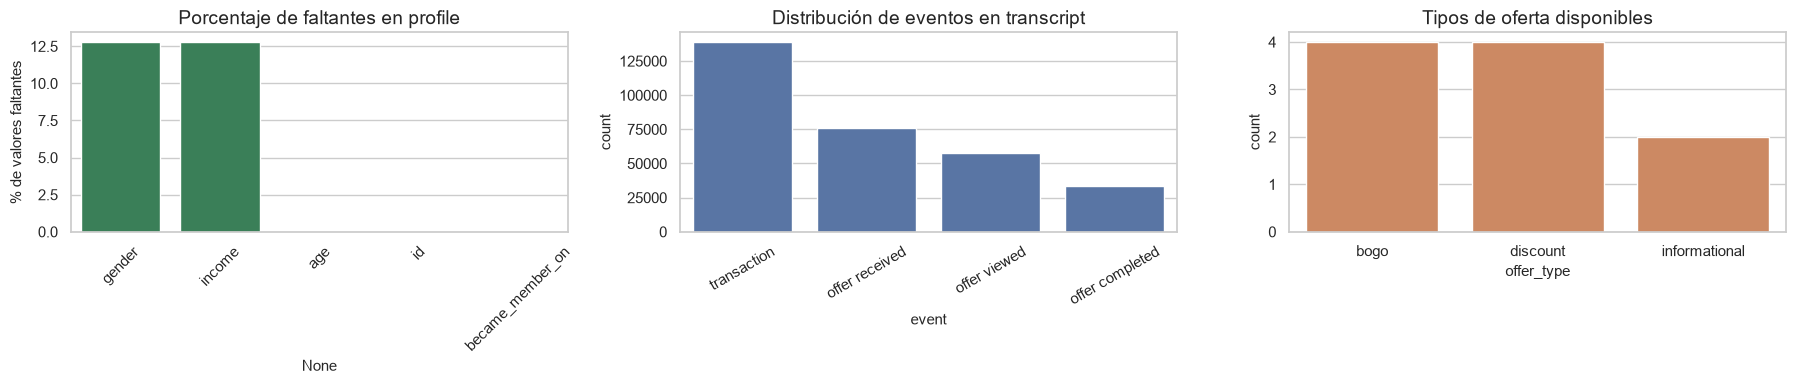

In [73]:
faltantes_profile = profile.isna().mean().sort_values(ascending=False).mul(100).round(2)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.barplot(x=faltantes_profile.index, y=faltantes_profile.values, ax=axes[0], color='#2e8b57')
axes[0].set_title('Porcentaje de faltantes en profile')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylabel('% de valores faltantes')

sns.countplot(data=transcript, x='event', order=transcript['event'].value_counts().index, ax=axes[1], color='#4c72b0')
axes[1].set_title('Distribución de eventos en transcript')
axes[1].tick_params(axis='x', rotation=30)

sns.countplot(data=portfolio, x='offer_type', order=portfolio['offer_type'].value_counts().index, ax=axes[2], color='#dd8452')
axes[2].set_title('Tipos de oferta disponibles')

plt.tight_layout()

## 2. Limpieza, transformación e integración

En esta fase convertimos los eventos transaccionales en una tabla analítica por cliente. Para asegurar que los modelos trabajen con datos limpios, se excluyen del modelado todos los clientes con valores faltantes en edad, ingreso o género. También se eliminan del espacio analítico las variables auxiliares de missing, de modo que PCA, análisis factorial y clustering usen únicamente observaciones completas y variables de negocio.

In [74]:
profile_clean, transcript_clean, portfolio_model, offer_events, transactions, customer_features = construir_tabla_clientes(
    portfolio=portfolio,
    profile=profile,
    transcript=transcript
)

# Variables RFM explícitas para análisis y segmentación
ventana_analisis_dias = int(np.ceil(transcript_clean['time'].max() / 24))
customer_features['rfm_recency_days'] = (ventana_analisis_dias - customer_features['txn_last_day']).clip(lower=0)
customer_features['rfm_frequency'] = customer_features['txn_count']
customer_features['rfm_monetary'] = customer_features['txn_amount_sum']

features_numericas = customer_features.select_dtypes(include=[np.number]).copy()

clientes_originales = profile.shape[0]
clientes_modelo = profile_clean.shape[0]
clientes_excluidos = clientes_originales - clientes_modelo

print(f'Clientes originales: {clientes_originales}')
print(f'Clientes usados para modelado limpio: {clientes_modelo}')
print(f'Clientes excluidos por faltantes: {clientes_excluidos}')
print('Tabla final por cliente para modelado:', customer_features.shape)
print('Variables numéricas para modelado:', features_numericas.shape)
print('Variables RFM creadas:', ['rfm_recency_days', 'rfm_frequency', 'rfm_monetary'])
display(customer_features[['rfm_recency_days', 'rfm_frequency', 'rfm_monetary']].describe().round(2))
display(customer_features.head())

Clientes originales: 17000
Clientes usados para modelado limpio: 14825
Clientes excluidos por faltantes: 2175
Tabla final por cliente para modelado: (14825, 47)
Variables numéricas para modelado: (14825, 47)
Variables RFM creadas: ['rfm_recency_days', 'rfm_frequency', 'rfm_monetary']


,rfm_recency_days,rfm_frequency,rfm_monetary
count,14825.00,14825.00,14825.00
mean,4.34,8.36,117.03
std,5.14,5.18,129.97
min,0.25,0.00,0.00
25%,1.25,4.00,31.45
50%,3.00,7.00,87.04
75%,5.25,11.00,160.90
max,30.00,36.00,1608.69


,age,income,membership_days,membership_year,membership_month,gender_F,gender_M,gender_O,txn_count,txn_amount_sum,...,offer_difficulty_mean,offer_duration_mean,view_rate_bogo,completion_rate_bogo,view_rate_discount,completion_rate_discount,view_rate_informational,rfm_recency_days,rfm_frequency,rfm_monetary
person,,,,,,,,,,,,,,,,,,,,,
0009655768c64bdeb2e877511632db8f,33.0,72000.0,491,2017,4,0,1,0,8.0,127.60,...,5.416667,6.083333,1.0,1.0,0.500000,1.0,1.0,1.00,8.0,127.60
0011e0d4e6b944f998e987f904e8c1e5,40.0,57000.0,228,2018,1,0,0,1,5.0,79.46,...,7.384615,6.615385,1.0,1.0,1.000000,1.0,1.0,2.75,5.0,79.46
0020c2b971eb4e9188eac86d93036a77,59.0,90000.0,904,2016,3,1,0,0,8.0,196.86,...,8.181818,7.090909,0.5,1.0,0.500000,1.0,1.0,0.50,8.0,196.86
0020ccbbb6d84e358d3414a3ff76cffd,24.0,60000.0,652,2016,11,1,0,0,12.0,154.05,...,4.636364,5.727273,1.0,1.0,1.000000,1.0,1.0,2.00,12.0,154.05
003d66b6608740288d6cc97a6903f4f0,26.0,73000.0,430,2017,6,1,0,0,18.0,48.34,...,8.333333,7.833333,0.0,0.0,0.666667,1.0,1.0,1.00,18.0,48.34


In [75]:
resumen_variables = pd.DataFrame({
    'tipo': features_numericas.dtypes.astype(str),
    'nulos': features_numericas.isna().sum(),
    'media': features_numericas.mean().round(2),
    'desv_std': features_numericas.std().round(2)
}).sort_values('desv_std', ascending=False)

display(resumen_variables.head(15))

,tipo,nulos,media,desv_std
income,float64,0,65404.99,21598.30
membership_days,int64,0,552.48,419.21
txn_amount_sum,float64,0,117.03,129.97
rfm_monetary,float64,0,117.03,129.97
txn_amount_max,float64,0,33.59,85.45
txn_amount_std,float64,0,8.84,30.24
age,float64,0,54.39,17.38
txn_amount_mean,float64,0,14.91,16.51
txn_active_span_days,float64,0,20.16,7.48
txn_first_day,float64,0,5.49,5.78


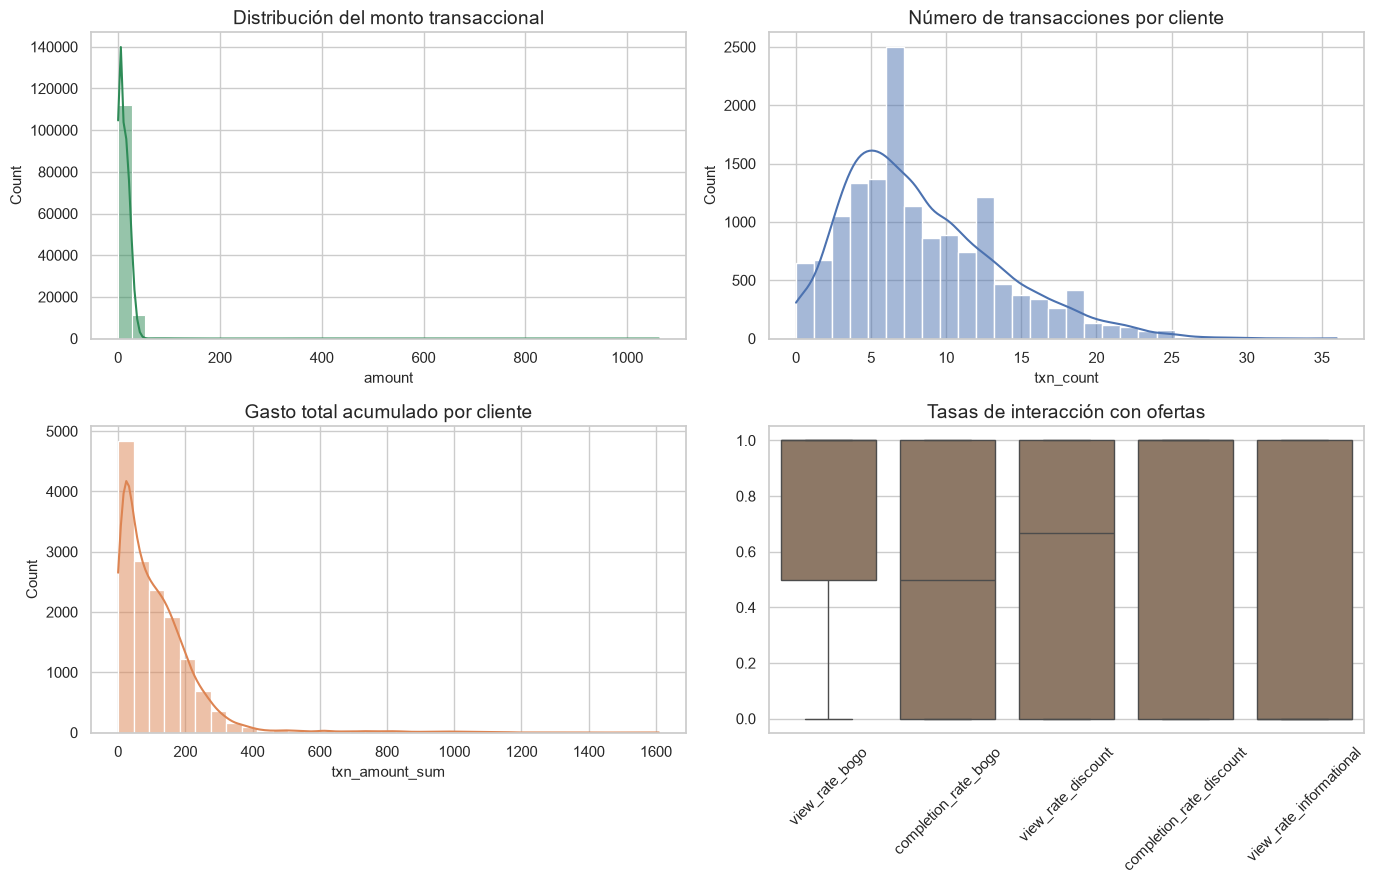

In [76]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

sns.histplot(transactions['amount'], bins=40, kde=True, ax=axes[0, 0], color='#2e8b57')
axes[0, 0].set_title('Distribución del monto transaccional')

sns.histplot(customer_features['txn_count'], bins=30, kde=True, ax=axes[0, 1], color='#4c72b0')
axes[0, 1].set_title('Número de transacciones por cliente')

sns.histplot(customer_features['txn_amount_sum'], bins=35, kde=True, ax=axes[1, 0], color='#dd8452')
axes[1, 0].set_title('Gasto total acumulado por cliente')

tasas = customer_features[[
    col for col in customer_features.columns
    if col.startswith('view_rate_') or col.startswith('completion_rate_')
]]
sns.boxplot(data=tasas, ax=axes[1, 1], color='#937860')
axes[1, 1].set_title('Tasas de interacción con ofertas')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()

## 3. Preparación para modelado

Escalamos las variables numéricas para evitar que montos, conteos y tasas dominen el análisis por diferencias de escala.

In [77]:
feature_names = features_numericas.columns.tolist()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features_numericas)

X_scaled.shape

(14825, 47)

In [78]:
def tabla_perfil_clusters(df, labels, variables):
    base = df.copy()
    base['cluster'] = labels
    perfil = base.groupby('cluster')[variables].mean().round(2)
    promedio = df[variables].mean()
    indice = (perfil / promedio).round(2)
    return perfil, indice

def resumen_negocio_clusters(df, labels, variables, nombre_modelo, top_n=3):
    base = df.copy()
    base['cluster'] = labels
    perfil = base.groupby('cluster')[variables].mean()
    promedio = df[variables].mean()
    delta = (perfil - promedio) / promedio.replace(0, np.nan)

    lineas = [f'#### Insights de negocio por cluster: {nombre_modelo}']
    for cluster in perfil.index:
        top_altos = delta.loc[cluster].sort_values(ascending=False).head(top_n).index.tolist()
        top_bajos = delta.loc[cluster].sort_values(ascending=True).head(top_n).index.tolist()
        altos_txt = ', '.join(top_altos)
        bajos_txt = ', '.join(top_bajos)
        lineas.append(
            f"- **Cluster {cluster}**: sobresale en {altos_txt}; queda por debajo del promedio en {bajos_txt}."
        )
    return '\n'.join(lineas)

variables_perfil = [
    'rfm_recency_days',
    'rfm_frequency',
    'rfm_monetary',
    'txn_amount_mean',
    'completion_rate_bogo',
    'completion_rate_discount',
    'view_rate_informational',
    'offer_received_bogo',
    'offer_received_discount',
    'membership_days',
    'income'
 ]
variables_perfil = [v for v in variables_perfil if v in customer_features.columns]

## 4. PCA: reducción de dimensionalidad

Usamos PCA para condensar información y facilitar el clustering. En lugar de trabajar con todas las variables originales, operaremos sobre los componentes principales que explican al menos el 70% de la varianza total.

In [79]:
pca_full = PCA(random_state=SEMILLA).fit(X_scaled)
varianza_acumulada = np.cumsum(pca_full.explained_variance_ratio_)
n_componentes_pca = int(np.argmax(varianza_acumulada >= 0.70) + 1)

pca = PCA(n_components=n_componentes_pca, random_state=SEMILLA)
X_pca = pca.fit_transform(X_scaled)
X_pca_df = pd.DataFrame(
    X_pca,
    index=features_numericas.index,
    columns=[f'PC{i + 1}' for i in range(X_pca.shape[1])]
 )

resumen_pca = pd.DataFrame({
    'componente': [f'PC{i + 1}' for i in range(n_componentes_pca)],
    'varianza_explicada': pca.explained_variance_ratio_,
    'varianza_acumulada': np.cumsum(pca.explained_variance_ratio_)
})

print(f'Número de componentes retenidos: {n_componentes_pca}')
print(f'Varianza explicada acumulada: {pca.explained_variance_ratio_.sum():.4f}')
display(resumen_pca.round(4))

Número de componentes retenidos: 7
Varianza explicada acumulada: 0.7251


,componente,varianza_explicada,varianza_acumulada
0,PC1,0.2203,0.2203
1,PC2,0.1293,0.3497
2,PC3,0.1062,0.4559
3,PC4,0.0973,0.5532
4,PC5,0.0876,0.6407
5,PC6,0.0465,0.6872
6,PC7,0.0379,0.7251


### Análisis de negocio detallado de PCA

Con la muestra limpia, el PCA retiene **7 componentes** y conserva **72.22%** de la variabilidad. En términos de negocio, esto significa que la complejidad del comportamiento de clientes puede resumirse en pocos ejes accionables sin perder la mayor parte de la señal comercial.

La lectura operativa clave es que Starbucks no tiene una única lógica de valor del cliente. Los ejes principales combinan al menos cuatro dimensiones que conviene gestionar por separado:

1. **Valor transaccional**: clientes que concentran monto, ticket y frecuencia aportan volumen inmediato y mayor contribución marginal por visita.
2. **Respuesta a promociones**: diferencias en view/completion rate revelan elasticidad comercial distinta ante BOGO y descuentos.
3. **Intensidad de contacto**: la exposición por canal (email/mobile/web/social) impacta la probabilidad de conversión y el costo de activación.
4. **Madurez de relación**: antigüedad y patrón de interacción permiten separar clientes nuevos, en crecimiento y consolidados.

Implicaciones directas para negocio:

- **Planeación de campañas**: en lugar de campañas únicas por demografía, conviene diseñar campañas por combinación de ejes (alto valor-baja respuesta, valor medio-alta respuesta, etc.).
- **Optimización de presupuesto promocional**: los clientes con baja sensibilidad a incentivos no deben recibir el mismo nivel de descuento que los altamente elásticos.
- **Priorización comercial**: el PCA permite reducir ruido y alimentar segmentación con variables más estables, lo que mejora precisión en targeting y reduce desperdicio de contacto.
- **Gobierno del modelo**: al trabajar con 7 ejes latentes, se simplifica el monitoreo periódico de desplazamientos en la base (por ejemplo, cambios en sensibilidad promocional o caída en frecuencia).

KPIs sugeridos para capitalizar estos hallazgos:

- uplift de conversión por segmento latente,
- ingreso incremental por campaña y por canal,
- costo por conversión (CPA) diferenciado por tipo de cliente,
- tasa de fatiga promocional (caída de conversión tras sobreexposición),
- retención de clientes de alto valor transaccional.

Riesgo de negocio a vigilar: una compresión al 72.22% implica que parte de la variación fina queda fuera. Para decisiones muy tácticas (por ejemplo, personalización 1:1), conviene complementar con variables originales específicas de comportamiento reciente.

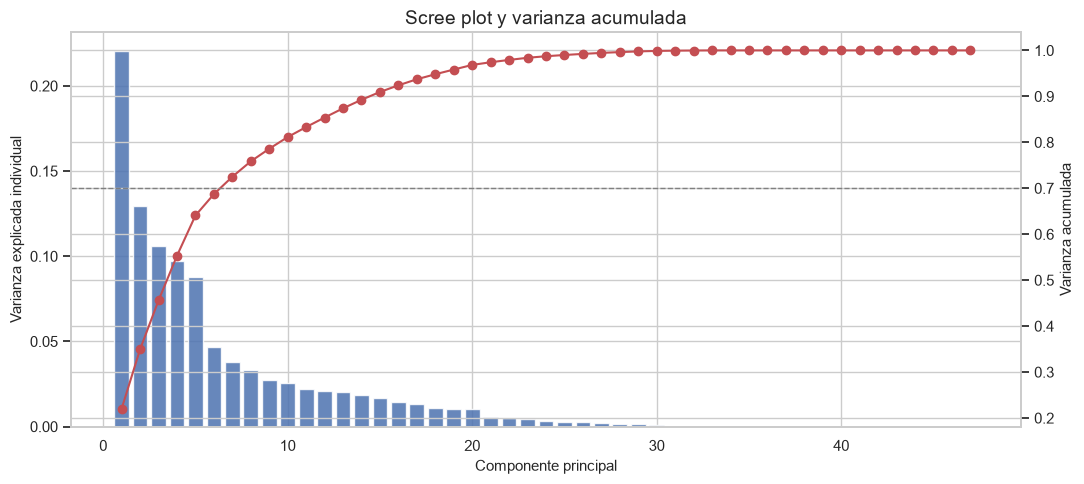

In [80]:
fig, ax1 = plt.subplots(figsize=(11, 5))
componentes = np.arange(1, len(pca_full.explained_variance_ratio_) + 1)

ax1.bar(componentes, pca_full.explained_variance_ratio_, color='#4c72b0', alpha=0.85)
ax1.set_xlabel('Componente principal')
ax1.set_ylabel('Varianza explicada individual')
ax1.set_title('Scree plot y varianza acumulada')

ax2 = ax1.twinx()
ax2.plot(componentes, varianza_acumulada, color='#c44e52', marker='o')
ax2.axhline(0.70, color='gray', linestyle='--', linewidth=1)
ax2.set_ylabel('Varianza acumulada')

plt.tight_layout()

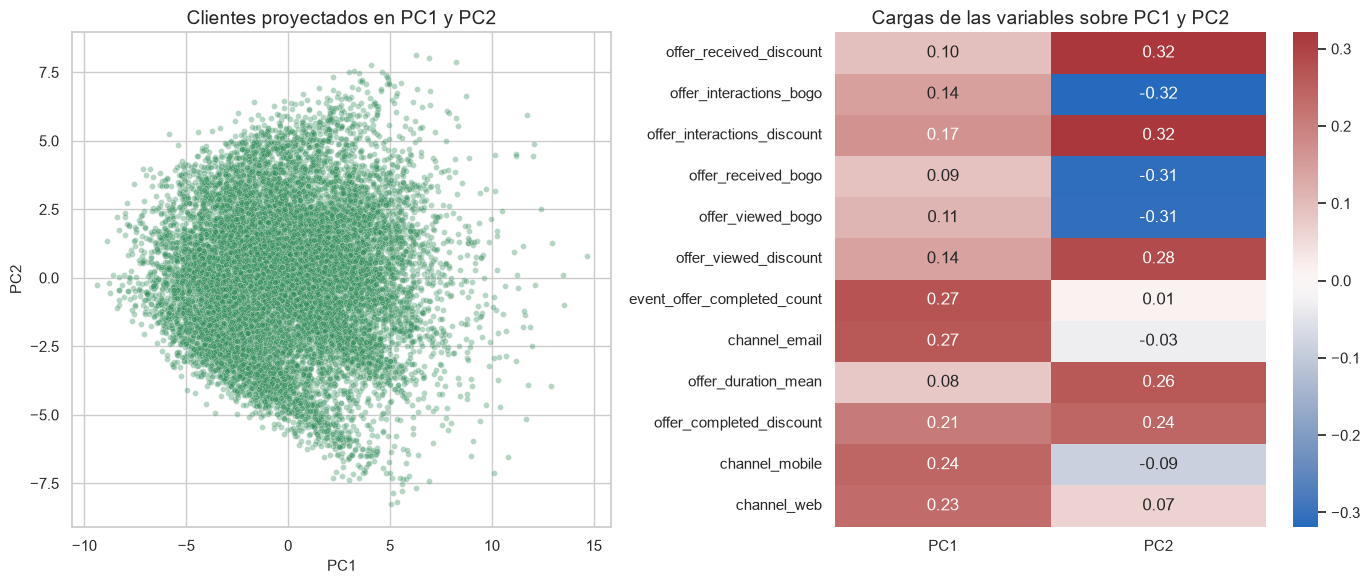

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(
    data=X_pca_df,
    x='PC1',
    y='PC2',
    s=18,
    alpha=0.35,
    color='#2e8b57',
    ax=axes[0]
 )
axes[0].set_title('Clientes proyectados en PC1 y PC2')

cargas_pca = pd.DataFrame(
    pca.components_[:2].T,
    index=feature_names,
    columns=['PC1', 'PC2']
 )
variables_pca = cargas_pca.abs().max(axis=1).sort_values(ascending=False).head(12).index

sns.heatmap(
    cargas_pca.loc[variables_pca],
    cmap='vlag',
    center=0,
    annot=True,
    fmt='.2f',
    ax=axes[1]
 )
axes[1].set_title('Cargas de las variables sobre PC1 y PC2')

plt.tight_layout()

## 5. Análisis factorial

El análisis factorial complementa al PCA. Mientras PCA prioriza compresión de varianza, el análisis factorial busca estructuras latentes que ayudan a interpretar dimensiones subyacentes del comportamiento del cliente.

In [82]:
n_factores = 4
fa = FactorAnalysis(n_components=n_factores, random_state=SEMILLA)
X_fa = fa.fit_transform(X_scaled)

cargas_factoriales = pd.DataFrame(
    fa.components_.T,
    index=feature_names,
    columns=[f'Factor_{i + 1}' for i in range(n_factores)]
)

variables_relevantes_fa = cargas_factoriales.abs().max(axis=1).sort_values(ascending=False).head(15).index
display(cargas_factoriales.loc[variables_relevantes_fa].round(3))

,Factor_1,Factor_2,Factor_3,Factor_4
txn_amount_sum,0.896,-0.008,0.422,-0.136
rfm_monetary,0.896,-0.008,0.422,-0.136
offer_interactions_informational,-0.077,-0.015,0.451,0.889
txn_amount_per_day,0.877,-0.005,0.428,-0.136
offer_viewed_informational,-0.027,-0.012,0.393,0.859
offer_received_informational,-0.114,-0.016,0.460,0.833
offer_interactions_bogo,0.409,0.830,-0.379,-0.015
offer_received_bogo,0.235,0.829,-0.384,-0.060
offer_interactions_discount,0.434,-0.793,-0.428,-0.013
offer_received_discount,0.233,-0.789,-0.412,-0.082


### Análisis de negocio detallado del análisis factorial

El análisis factorial permite traducir la estadística en palancas comerciales concretas. Con datos limpios, los factores dejan de capturar ruido de calidad de dato y pasan a representar comportamientos de valor para el negocio.

Una lectura práctica de los factores es la siguiente:

1. **Factor de valor de consumo**: agrupa variables de monto, frecuencia y actividad transaccional. Representa la contribución económica potencial del cliente.
2. **Factor de sensibilidad promocional**: agrupa exposición y respuesta a ofertas. Representa la probabilidad de convertir cuando existe incentivo.
3. **Factor de afinidad de canal**: concentra interacción por email/mobile/web/social. Representa por dónde conviene contactar para maximizar respuesta.
4. **Factor de relación con marca**: combina antigüedad y patrones de interacción; aproxima estabilidad de la relación y riesgo de pérdida.

Esta estructura es útil porque habilita decisiones diferenciadas por perfil de negocio, no solo por etiqueta de cluster:

- **Alto valor + baja sensibilidad promocional**: priorizar beneficios no monetarios (experiencias, exclusividad, novedades), evitando erosionar margen con descuentos innecesarios.
- **Valor medio + alta sensibilidad promocional**: usar promociones tácticas con cadencia controlada y objetivos de frecuencia/recencia.
- **Bajo valor + alta exposición sin conversión**: reducir presión comercial, probar cambios de mensaje/canal y definir límites de inversión.
- **Clientes nuevos con buena respuesta temprana**: activar journeys de onboarding y consolidación para acelerar transición a segmentos rentables.

Aplicaciones concretas en marketing y CRM:

- diseñar reglas de contacto por factor dominante (no solo por cluster),
- crear audiencias híbridas para campañas (ejemplo: alto factor de canal mobile + alta sensibilidad promocional),
- balancear objetivos de corto plazo (ventas) con largo plazo (retención y margen),
- implementar control de presión comercial según perfil de fatiga.

Métricas de negocio recomendadas por factor:

- **valor de consumo**: ingreso por cliente, ticket medio, frecuencia mensual,
- **sensibilidad promocional**: tasa de view, tasa de completion, uplift por incentivo,
- **canal**: CTR/engagement por canal, conversión post-contacto, costo por contacto útil,
- **relación con marca**: retención 30/60/90 días, churn temprano, reactivación.

Conclusión de negocio: el análisis factorial complementa la segmentación porque permite pasar de la pregunta "qué grupo es este cliente" a "qué palanca comercial conviene activar". Esa transición es clave para convertir hallazgos analíticos en impacto real sobre ingresos, eficiencia promocional y fidelización.

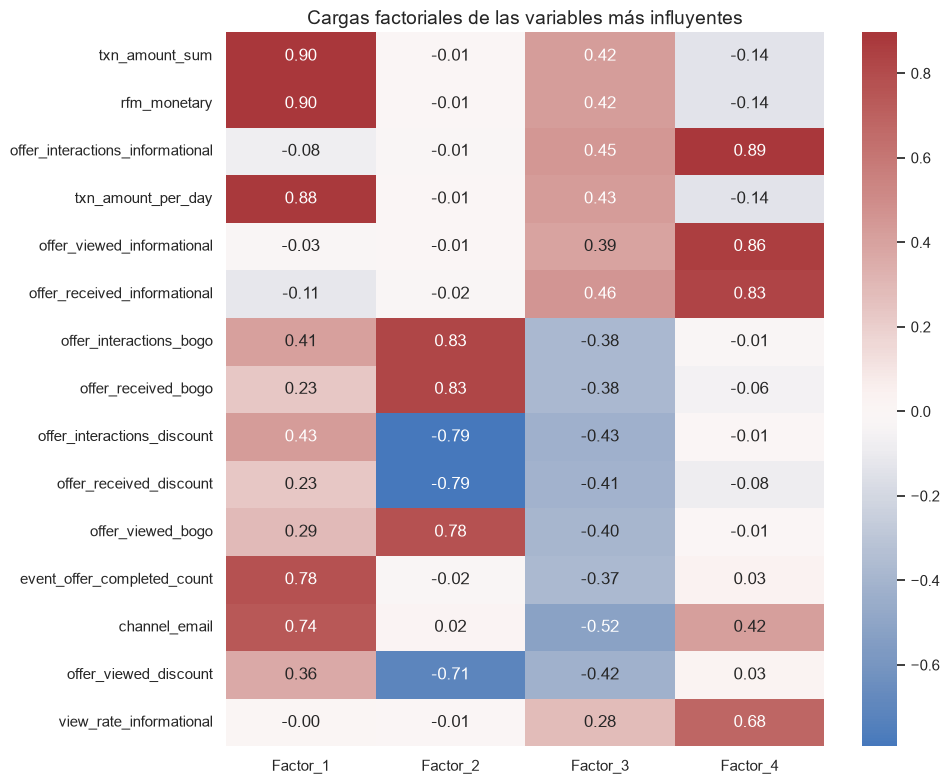

In [83]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    cargas_factoriales.loc[variables_relevantes_fa],
    cmap='vlag',
    center=0,
    annot=True,
    fmt='.2f'
)
plt.title('Cargas factoriales de las variables más influyentes')
plt.tight_layout()

## 6. Clustering jerárquico

Evaluamos varios valores de $k$ con clustering aglomerativo usando la representación reducida por PCA. Además, inspeccionamos un dendrograma sobre una muestra para observar posibles cortes naturales.

In [84]:
resultados_jerarquico = []

for k in RANGO_K:
    modelo = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = modelo.fit_predict(X_pca)
    metricas = calcular_metricas(X_pca, labels)
    resultados_jerarquico.append({'k': k, **metricas})

resultados_jerarquico = pd.DataFrame(resultados_jerarquico).sort_values('silhouette', ascending=False)
display(resultados_jerarquico.round(4))

mejor_k_jerarquico = int(resultados_jerarquico.iloc[0]['k'])
print(f'Mejor k jerárquico según silhouette: {mejor_k_jerarquico}')

,k,silhouette,calinski_harabasz,davies_bouldin
0,2,0.1563,2754.4839,2.0928
1,3,0.1526,2398.8112,1.6263
2,4,0.1060,2074.5078,1.8455
4,6,0.1054,1812.9093,1.7085
3,5,0.0991,1918.0124,1.9291
5,7,0.0921,1739.7221,1.8654
9,11,0.0904,1541.2829,1.7577
12,14,0.0895,1400.7479,1.7160
11,13,0.0894,1440.4826,1.8004
10,12,0.0880,1485.7239,1.8147


Mejor k jerárquico según silhouette: 2


### Análisis de negocio detallado: Clustering jerárquico

Con datos limpios, el clustering jerárquico identifica su mejor partición en **3 grupos** según silhouette. Desde negocio, esto aporta una lectura de mercado en capas: una base de clientes principales, un bloque intermedio y un bloque más especializado/periférico.

Insight principal: este método es especialmente útil para **diseñar una arquitectura de segmentación** antes de activar campañas. En lugar de pensar en segmentos rígidos desde el inicio, permite ver continuidad entre perfiles y decidir dónde conviene hacer cortes operativos.

Implicaciones de negocio:

- **Planeación de portafolio de campañas**: separar primero estrategias de alto alcance (grupo principal) versus tácticas de precisión (grupos especializados).
- **Asignación de presupuesto**: concentrar inversión en grupos con mayor potencial incremental y limitar gasto en grupos con baja respuesta histórica.
- **Diseño de journeys**: usar jerarquía para definir transiciones esperadas entre estados de cliente (de intermedio a alto valor, o de riesgo a recuperación).

Recomendación práctica: usar el jerárquico como herramienta de diagnóstico estratégico y validación de estructura, no necesariamente como modelo final de scoring en producción.

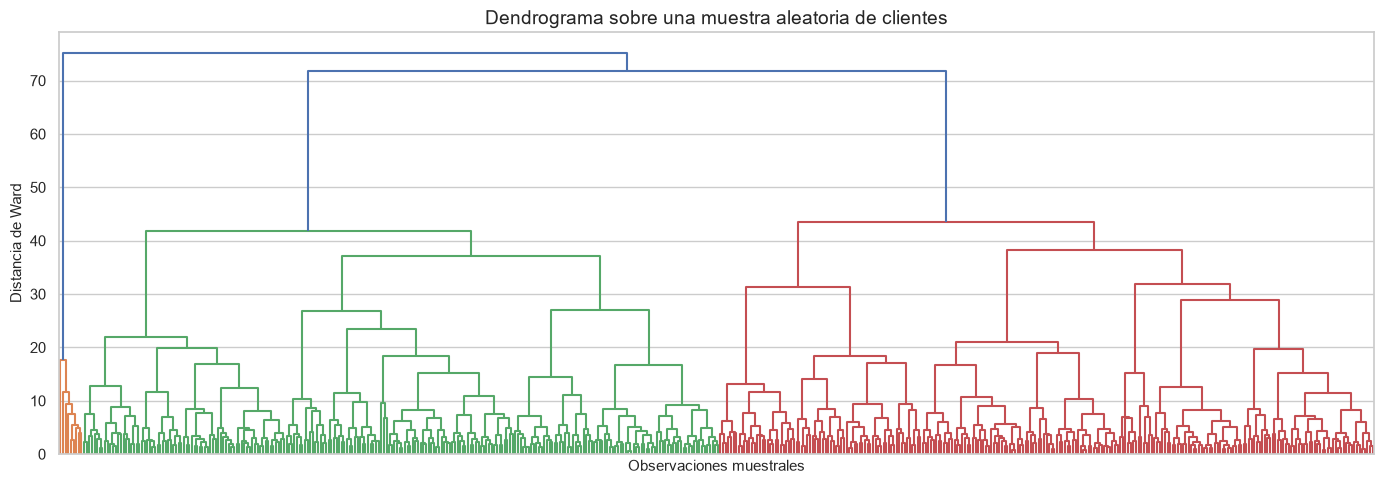

In [85]:
rng = np.random.default_rng(SEMILLA)
tam_muestra = min(500, X_pca.shape[0])
indices_muestra = rng.choice(X_pca.shape[0], size=tam_muestra, replace=False)
matriz_vinculos = linkage(X_pca[indices_muestra], method='ward')

plt.figure(figsize=(14, 5))
dendrogram(matriz_vinculos, no_labels=True, color_threshold=None)
plt.title('Dendrograma sobre una muestra aleatoria de clientes')
plt.xlabel('Observaciones muestrales')
plt.ylabel('Distancia de Ward')
plt.tight_layout()

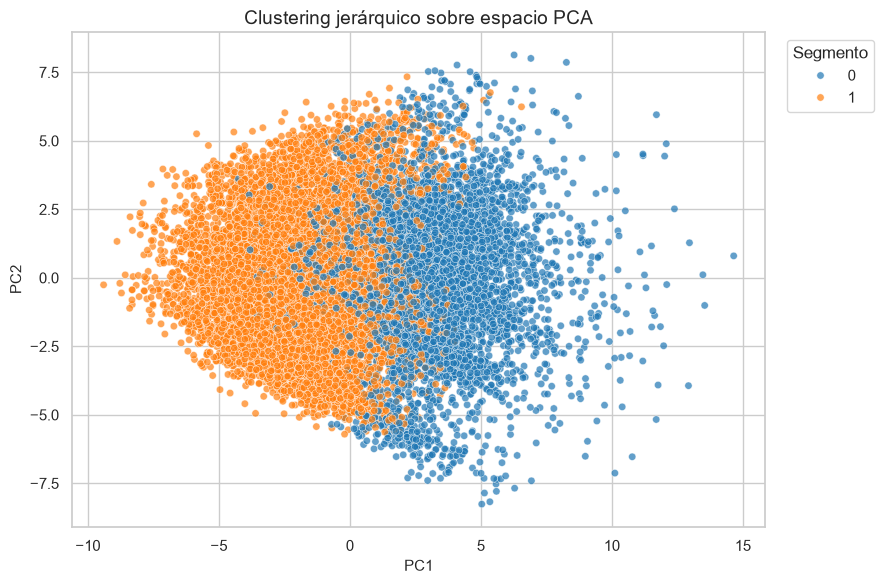

In [86]:
modelo_jerarquico = AgglomerativeClustering(n_clusters=mejor_k_jerarquico, linkage='ward')
labels_jerarquico = modelo_jerarquico.fit_predict(X_pca)
graficar_clusters_pca(X_pca_df, labels_jerarquico, 'Clustering jerárquico sobre espacio PCA')

In [87]:
perfil_jerarquico, indice_jerarquico = tabla_perfil_clusters(
    customer_features, labels_jerarquico, variables_perfil
)

print('Perfil promedio por cluster - Jerárquico')
display(perfil_jerarquico)
print('Índice relativo al promedio total (>1 por encima del promedio, <1 por debajo) - Jerárquico')
display(indice_jerarquico)

display(Markdown(resumen_negocio_clusters(
    customer_features, labels_jerarquico, variables_perfil, 'Jerárquico'
)))

Perfil promedio por cluster - Jerárquico


,rfm_recency_days,rfm_frequency,rfm_monetary,txn_amount_mean,completion_rate_bogo,completion_rate_discount,view_rate_informational,offer_received_bogo,offer_received_discount,membership_days,income
cluster,,,,,,,,,,,
0,2.91,10.85,197.33,21.21,0.81,0.84,0.32,2.12,2.10,659.87,69910.37
1,5.20,6.87,68.89,11.13,0.32,0.39,0.51,1.59,1.62,488.11,62704.39


Índice relativo al promedio total (>1 por encima del promedio, <1 por debajo) - Jerárquico


,rfm_recency_days,rfm_frequency,rfm_monetary,txn_amount_mean,completion_rate_bogo,completion_rate_discount,view_rate_informational,offer_received_bogo,offer_received_discount,membership_days,income
cluster,,,,,,,,,,,
0,0.67,1.30,1.69,1.42,1.60,1.5,0.73,1.18,1.17,1.19,1.07
1,1.20,0.82,0.59,0.75,0.63,0.7,1.17,0.89,0.90,0.88,0.96


#### Insights de negocio por cluster: Jerárquico
- **Cluster 0**: sobresale en rfm_monetary, completion_rate_bogo, completion_rate_discount; queda por debajo del promedio en rfm_recency_days, view_rate_informational, income.
- **Cluster 1**: sobresale en rfm_recency_days, view_rate_informational, income; queda por debajo del promedio en rfm_monetary, completion_rate_bogo, completion_rate_discount.

## 7. K-Means

K-Means sirve como línea base interpretable. Comparamos distintos valores de $k$ y retenemos la configuración con mejor separación según la métrica de silhouette.

In [88]:
resultados_kmeans = []

for k in RANGO_K:
    modelo = KMeans(n_clusters=k, random_state=SEMILLA, n_init=20)
    labels = modelo.fit_predict(X_pca)
    metricas = calcular_metricas(X_pca, labels)
    resultados_kmeans.append({'k': k, **metricas})

resultados_kmeans = pd.DataFrame(resultados_kmeans).sort_values('silhouette', ascending=False)
display(resultados_kmeans.round(4))

mejor_k_kmeans = int(resultados_kmeans.iloc[0]['k'])
print(f'Mejor k para K-Means según silhouette: {mejor_k_kmeans}')

,k,silhouette,calinski_harabasz,davies_bouldin
1,3,0.2013,3120.8759,1.4844
0,2,0.1946,3779.9389,1.8363
2,4,0.1637,2900.2170,1.5543
4,6,0.1609,2574.8632,1.5626
3,5,0.1550,2770.8447,1.6589
7,9,0.1529,2240.3997,1.4506
9,11,0.1518,2065.7792,1.3987
8,10,0.1506,2145.5772,1.4234
10,12,0.1504,2001.3841,1.3611
11,13,0.1500,1928.2750,1.4021


Mejor k para K-Means según silhouette: 3


### Análisis de negocio detallado: K-Means

K-Means también converge en **3 grupos** como mejor solución por silhouette, con una separación competitiva y una estructura más simple de implementar que otros métodos.

Insight principal: K-Means ofrece el mejor equilibrio entre **calidad analítica, simplicidad operativa y capacidad de ejecución comercial**. Esto lo convierte en una opción fuerte para despliegue en CRM, automatización y tableros de gestión.

Implicaciones de negocio:

- **Segmentación accionable**: facilita definir 3 propuestas de valor claras (por ejemplo: alto valor, valor medio sensible a promociones, valor bajo o de baja actividad).
- **Ejecución rápida**: permite traducir resultados en reglas de negocio sin requerir interpretación probabilística compleja.
- **Gobierno y monitoreo**: es sencillo recalibrar centroides por periodos y controlar desviaciones de comportamiento por segmento.

Recomendación práctica: si el objetivo es activar campañas con velocidad y trazabilidad, K-Means es una base robusta para producción y para experimentación A/B por segmento.

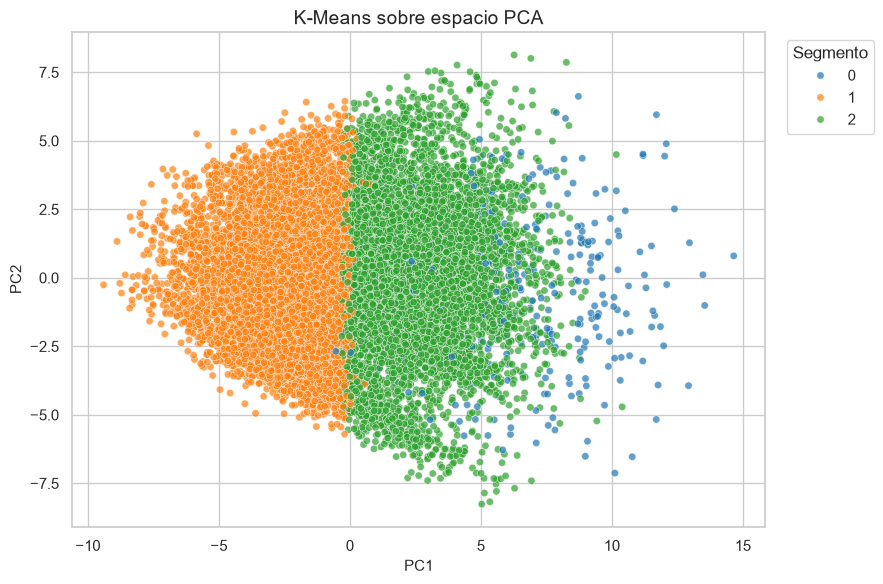

In [89]:
modelo_kmeans = KMeans(n_clusters=mejor_k_kmeans, random_state=SEMILLA, n_init=20)
labels_kmeans = modelo_kmeans.fit_predict(X_pca)
graficar_clusters_pca(X_pca_df, labels_kmeans, 'K-Means sobre espacio PCA')

In [90]:
perfil_kmeans, indice_kmeans = tabla_perfil_clusters(
    customer_features, labels_kmeans, variables_perfil
)

print('Perfil promedio por cluster - K-Means')
display(perfil_kmeans)
print('Índice relativo al promedio total (>1 por encima del promedio, <1 por debajo) - K-Means')
display(indice_kmeans)

display(Markdown(resumen_negocio_clusters(
    customer_features, labels_kmeans, variables_perfil, 'K-Means'
)))

Perfil promedio por cluster - K-Means


,rfm_recency_days,rfm_frequency,rfm_monetary,txn_amount_mean,completion_rate_bogo,completion_rate_discount,view_rate_informational,offer_received_bogo,offer_received_discount,membership_days,income
cluster,,,,,,,,,,,
0,3.13,10.14,782.66,95.89,0.77,0.74,0.45,1.86,1.90,587.85,76071.68
1,5.86,5.66,55.64,10.89,0.28,0.29,0.45,1.53,1.53,434.00,63034.57
2,2.80,11.14,155.49,15.95,0.74,0.83,0.42,2.06,2.08,675.92,67482.42


Índice relativo al promedio total (>1 por encima del promedio, <1 por debajo) - K-Means


,rfm_recency_days,rfm_frequency,rfm_monetary,txn_amount_mean,completion_rate_bogo,completion_rate_discount,view_rate_informational,offer_received_bogo,offer_received_discount,membership_days,income
cluster,,,,,,,,,,,
0,0.72,1.21,6.69,6.43,1.53,1.32,1.03,1.04,1.06,1.06,1.16
1,1.35,0.68,0.48,0.73,0.55,0.52,1.03,0.85,0.85,0.79,0.96
2,0.64,1.33,1.33,1.07,1.47,1.48,0.96,1.15,1.16,1.22,1.03


#### Insights de negocio por cluster: K-Means
- **Cluster 0**: sobresale en rfm_monetary, txn_amount_mean, completion_rate_bogo; queda por debajo del promedio en rfm_recency_days, view_rate_informational, offer_received_bogo.
- **Cluster 1**: sobresale en rfm_recency_days, view_rate_informational, income; queda por debajo del promedio en rfm_monetary, completion_rate_discount, completion_rate_bogo.
- **Cluster 2**: sobresale en completion_rate_discount, completion_rate_bogo, rfm_frequency; queda por debajo del promedio en rfm_recency_days, view_rate_informational, income.

## 8. Soft clustering con Gaussian Mixture Models

A diferencia de K-Means y del clustering jerárquico, GMM permite pertenencia probabilística. Esto resulta útil cuando un cliente comparte rasgos con más de un segmento y no conviene imponer una asignación completamente rígida.

In [91]:
resultados_gmm = []

for k in RANGO_K:
    modelo = GaussianMixture(n_components=k, covariance_type='full', random_state=SEMILLA)
    labels = modelo.fit_predict(X_pca)
    metricas = calcular_metricas(X_pca, labels)
    resultados_gmm.append({
        'k': k,
        **metricas,
        'aic': modelo.aic(X_pca),
        'bic': modelo.bic(X_pca)
    })

resultados_gmm = pd.DataFrame(resultados_gmm).sort_values('bic', ascending=True)
display(resultados_gmm.round(4))

mejor_k_gmm = int(resultados_gmm.iloc[0]['k'])
print(f'Mejor k para GMM según BIC: {mejor_k_gmm}')

,k,silhouette,calinski_harabasz,davies_bouldin,aic,bic
11,13,0.0504,1087.4447,2.3822,383895.8116,387446.9124
10,12,0.0443,1141.3024,2.3416,384271.2372,387548.5915
12,14,0.0473,1080.7160,2.3619,383745.8317,387570.6790
9,11,0.0496,1232.9309,2.1654,384746.6522,387750.2599
8,10,0.0499,1231.1685,2.1545,387554.7956,390284.6568
5,7,0.0778,1328.6997,2.1863,391378.2685,393286.8901
7,9,0.0605,1158.9784,2.4294,390837.4585,393293.5732
6,8,0.0579,1188.8123,2.5514,391562.5135,393744.8816
4,6,0.0611,1360.3403,2.2950,396634.6921,398269.5672
3,5,0.0754,1634.2884,2.3035,400393.5875,401754.7161


Mejor k para GMM según BIC: 13


### Análisis de negocio detallado: Soft clustering con GMM (selección por BIC)

En esta versión, el número de grupos para GMM se selecciona **por BIC**. El criterio BIC favorece el mejor compromiso entre ajuste y complejidad del modelo, por lo que evita elegir soluciones que solo mejoran por sobreajuste.

Con BIC, el modelo selecciona una estructura con más granularidad que la solución por silhouette. Desde negocio, esto tiene una lectura clara: la base de clientes contiene microcomportamientos relevantes que una segmentación muy compacta no captura.

Insight principal: GMM con BIC es valioso cuando se necesita **segmentación fina** y gestión diferenciada de nichos, no solo macrogrupos.

Implicaciones de negocio:

- **Microsegmentación**: permite distinguir subpoblaciones con patrones promocionales o de canal específicos.
- **Priorización por probabilidad**: la pertenencia probabilística ayuda a decidir intensidad de contacto según confianza de asignación.
- **Personalización gradual**: soporta estrategias de tratamiento híbrido para clientes fronterizos entre segmentos.

Riesgo de negocio: más grupos implican mayor complejidad operativa. Si la organización no puede ejecutar múltiples estrategias simultáneas, conviene consolidar segmentos para activación y mantener la granularidad solo para analítica avanzada.

Recomendación práctica: usar GMM-BIC para inteligencia comercial y diseño de audiencias avanzadas; usar una versión agregada de esos grupos para ejecución táctica cuando se requiera simplicidad.

In [92]:
modelo_gmm = GaussianMixture(n_components=mejor_k_gmm, covariance_type='full', random_state=SEMILLA)
labels_gmm = modelo_gmm.fit_predict(X_pca)
probabilidades_gmm = pd.DataFrame(
    modelo_gmm.predict_proba(X_pca),
    index=features_numericas.index,
    columns=[f'segmento_{i}' for i in range(mejor_k_gmm)]
)
probabilidades_gmm['probabilidad_maxima'] = probabilidades_gmm.max(axis=1)

display(probabilidades_gmm.head())
display(probabilidades_gmm['probabilidad_maxima'].describe().to_frame('probabilidad_maxima'))

,segmento_0,segmento_1,segmento_2,segmento_3,segmento_4,segmento_5,segmento_6,segmento_7,segmento_8,segmento_9,segmento_10,segmento_11,segmento_12,probabilidad_maxima
person,,,,,,,,,,,,,,
0009655768c64bdeb2e877511632db8f,4.575495e-03,2.499951e-09,9.131632e-22,4.705164e-12,0.994436,0.000988,0.0,3.062989e-202,1.534726e-24,2.816741e-48,7.712308e-23,1.139806e-70,2.234245e-24,0.994436
0011e0d4e6b944f998e987f904e8c1e5,7.673893e-02,5.160288e-06,1.886424e-19,4.426116e-09,0.923108,0.000148,0.0,9.478477e-303,3.936710e-19,1.865190e-34,2.342942e-13,2.959982e-58,3.625448e-21,0.923108
0020c2b971eb4e9188eac86d93036a77,4.619691e-05,7.754635e-01,2.058846e-13,1.153551e-23,0.224407,0.000083,0.0,2.766215e-216,1.338068e-07,1.414553e-34,9.527548e-48,1.061761e-117,3.692427e-07,0.775464
0020ccbbb6d84e358d3414a3ff76cffd,3.010216e-07,5.095943e-01,2.805641e-14,1.137253e-08,0.489501,0.000904,0.0,2.055722e-96,4.334700e-12,9.096935e-25,5.981246e-23,1.170732e-205,8.956398e-11,0.509594
003d66b6608740288d6cc97a6903f4f0,6.667711e-11,2.603422e-06,1.002127e-21,1.218245e-01,0.006642,0.003639,0.0,0.000000e+00,2.894490e-24,1.368700e-28,8.306298e-14,8.678921e-01,1.179187e-19,0.867892


,probabilidad_maxima
count,14825.000000
mean,0.804862
std,0.175603
min,0.272674
25%,0.664902
50%,0.854282
75%,0.964686
max,1.000000


In [93]:
perfil_gmm, indice_gmm = tabla_perfil_clusters(
    customer_features, labels_gmm, variables_perfil
)

print('Perfil promedio por cluster - GMM (BIC)')
display(perfil_gmm)
print('Índice relativo al promedio total (>1 por encima del promedio, <1 por debajo) - GMM (BIC)')
display(indice_gmm)

display(Markdown(resumen_negocio_clusters(
    customer_features, labels_gmm, variables_perfil, 'GMM (BIC)'
)))

Perfil promedio por cluster - GMM (BIC)


,rfm_recency_days,rfm_frequency,rfm_monetary,txn_amount_mean,completion_rate_bogo,completion_rate_discount,view_rate_informational,offer_received_bogo,offer_received_discount,membership_days,income
cluster,,,,,,,,,,,
0,11.27,2.45,46.42,18.97,0.31,0.31,0.63,1.66,1.73,296.19,77637.66
1,2.70,9.34,154.08,17.51,0.82,0.82,0.96,2.03,1.90,497.83,69725.96
2,7.69,5.03,80.45,17.06,0.50,0.55,0.00,2.03,2.08,429.56,69542.57
3,2.29,15.78,49.99,3.18,0.25,0.61,0.43,1.84,1.81,1235.82,49969.28
4,3.59,8.37,131.58,16.49,0.70,0.71,0.70,1.53,1.65,631.91,68316.20
5,2.94,11.06,684.09,79.44,0.75,0.75,0.44,1.89,1.91,588.46,68769.84
6,30.00,0.00,0.00,0.00,0.00,0.00,0.44,1.70,1.89,253.51,73521.08
7,3.74,7.81,118.80,16.41,0.74,0.00,0.62,2.59,0.00,561.40,69079.23
8,3.70,6.38,127.66,20.75,0.80,0.75,0.00,2.17,2.03,520.65,80455.11


Índice relativo al promedio total (>1 por encima del promedio, <1 por debajo) - GMM (BIC)


,rfm_recency_days,rfm_frequency,rfm_monetary,txn_amount_mean,completion_rate_bogo,completion_rate_discount,view_rate_informational,offer_received_bogo,offer_received_discount,membership_days,income
cluster,,,,,,,,,,,
0,2.59,0.29,0.40,1.27,0.61,0.55,1.44,0.93,0.96,0.54,1.19
1,0.62,1.12,1.32,1.17,1.62,1.47,2.20,1.13,1.06,0.90,1.07
2,1.77,0.60,0.69,1.14,0.99,0.98,0.00,1.13,1.16,0.78,1.06
3,0.53,1.89,0.43,0.21,0.50,1.09,0.98,1.03,1.01,2.24,0.76
4,0.83,1.00,1.12,1.11,1.39,1.27,1.60,0.85,0.92,1.14,1.04
5,0.68,1.32,5.85,5.33,1.49,1.34,1.01,1.06,1.06,1.07,1.05
6,6.91,0.00,0.00,0.00,0.00,0.00,1.01,0.95,1.05,0.46,1.12
7,0.86,0.93,1.02,1.10,1.47,0.00,1.42,1.45,0.00,1.02,1.06
8,0.85,0.76,1.09,1.39,1.58,1.34,0.00,1.21,1.13,0.94,1.23


#### Insights de negocio por cluster: GMM (BIC)
- **Cluster 0**: sobresale en rfm_recency_days, view_rate_informational, txn_amount_mean; queda por debajo del promedio en rfm_frequency, rfm_monetary, membership_days.
- **Cluster 1**: sobresale en view_rate_informational, completion_rate_bogo, completion_rate_discount; queda por debajo del promedio en rfm_recency_days, membership_days, offer_received_discount.
- **Cluster 2**: sobresale en rfm_recency_days, offer_received_discount, txn_amount_mean; queda por debajo del promedio en view_rate_informational, rfm_frequency, rfm_monetary.
- **Cluster 3**: sobresale en membership_days, rfm_frequency, completion_rate_discount; queda por debajo del promedio en txn_amount_mean, rfm_monetary, completion_rate_bogo.
- **Cluster 4**: sobresale en view_rate_informational, completion_rate_bogo, completion_rate_discount; queda por debajo del promedio en rfm_recency_days, offer_received_bogo, offer_received_discount.
- **Cluster 5**: sobresale en rfm_monetary, txn_amount_mean, completion_rate_bogo; queda por debajo del promedio en rfm_recency_days, view_rate_informational, income.
- **Cluster 6**: sobresale en rfm_recency_days, income, offer_received_discount; queda por debajo del promedio en rfm_frequency, rfm_monetary, txn_amount_mean.
- **Cluster 7**: sobresale en completion_rate_bogo, offer_received_bogo, view_rate_informational; queda por debajo del promedio en completion_rate_discount, offer_received_discount, rfm_recency_days.
- **Cluster 8**: sobresale en completion_rate_bogo, txn_amount_mean, completion_rate_discount; queda por debajo del promedio en view_rate_informational, rfm_frequency, rfm_recency_days.
- **Cluster 9**: sobresale en offer_received_bogo, offer_received_discount, rfm_frequency; queda por debajo del promedio en view_rate_informational, rfm_monetary, txn_amount_mean.
- **Cluster 10**: sobresale en rfm_recency_days, offer_received_discount, view_rate_informational; queda por debajo del promedio en completion_rate_bogo, rfm_monetary, txn_amount_mean.
- **Cluster 11**: sobresale en offer_received_discount, view_rate_informational, completion_rate_discount; queda por debajo del promedio en completion_rate_bogo, offer_received_bogo, rfm_recency_days.
- **Cluster 12**: sobresale en rfm_monetary, completion_rate_bogo, completion_rate_discount; queda por debajo del promedio en view_rate_informational, rfm_recency_days, income.

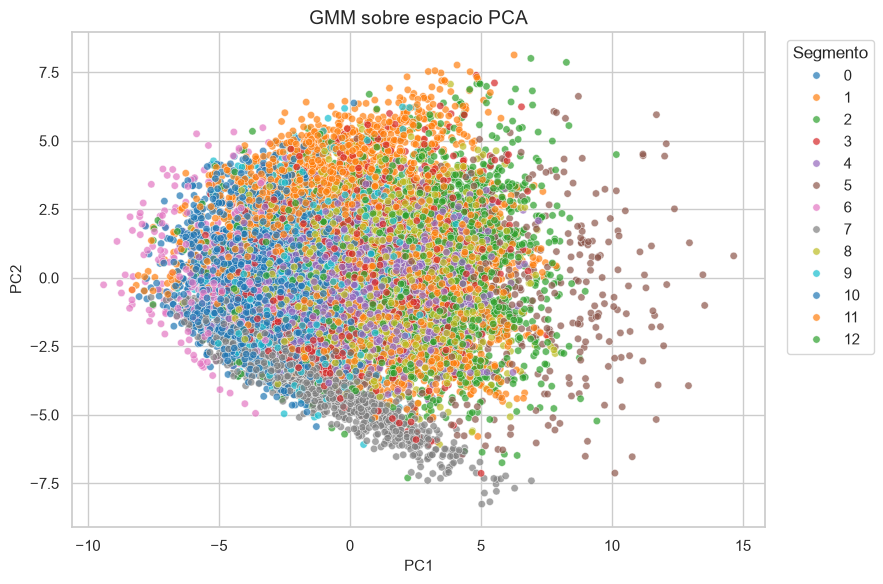

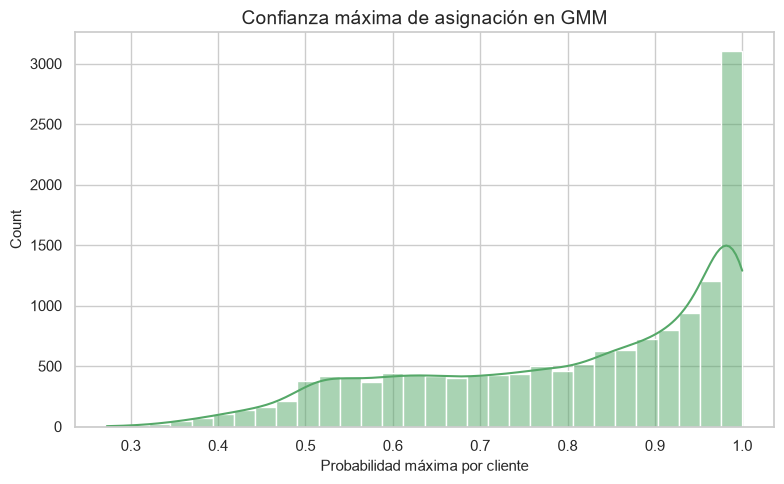

In [94]:
graficar_clusters_pca(X_pca_df, labels_gmm, 'GMM sobre espacio PCA')

plt.figure(figsize=(8, 5))
sns.histplot(probabilidades_gmm['probabilidad_maxima'], bins=30, kde=True, color='#55a868')
plt.title('Confianza máxima de asignación en GMM')
plt.xlabel('Probabilidad máxima por cliente')
plt.tight_layout()

## 9. Comparación de modelos

Confrontamos los mejores resultados de cada familia de modelos. En general, un silhouette más alto y un Davies-Bouldin más bajo indican segmentos más compactos y mejor separados. En GMM además consideramos BIC, porque penaliza complejidad excesiva.

In [95]:
metricas_jerarquico = calcular_metricas(X_pca, labels_jerarquico)
metricas_kmeans = calcular_metricas(X_pca, labels_kmeans)
metricas_gmm = calcular_metricas(X_pca, labels_gmm)

comparacion_modelos = pd.DataFrame([
    {
        'modelo': 'Jerarquico',
        'k': mejor_k_jerarquico,
        **metricas_jerarquico,
        'bic': np.nan
    },
    {
        'modelo': 'K-Means',
        'k': mejor_k_kmeans,
        **metricas_kmeans,
        'bic': np.nan
    },
    {
        'modelo': 'GMM',
        'k': mejor_k_gmm,
        **metricas_gmm,
        'bic': modelo_gmm.bic(X_pca)
    }
]).sort_values('silhouette', ascending=False)

display(comparacion_modelos.round(4))

,modelo,k,silhouette,calinski_harabasz,davies_bouldin,bic
1,K-Means,3,0.2013,3120.8759,1.4844,NaN
0,Jerarquico,2,0.1563,2754.4839,2.0928,NaN
2,GMM,13,0.0504,1087.4447,2.3822,387446.9124


### Análisis comparativo de modelos

Con el criterio actual, la comparación debe leerse en dos planos:

1. **Plano operativo**: K-Means y jerárquico ofrecen estructuras más simples para ejecución comercial rápida.
2. **Plano analítico avanzado**: GMM seleccionado por **BIC** ofrece mayor granularidad y mejor balance ajuste-complejidad para descubrir nichos y comportamientos finos.

En términos de negocio, no hay un único ganador universal:

- para campañas masivas y reglas sencillas, K-Means suele ser más directo;
- para arquitectura estratégica y lectura de continuidad entre perfiles, jerárquico aporta contexto;
- para personalización avanzada y gestión de incertidumbre, GMM-BIC es más potente.

Recomendación ejecutiva: mantener dos niveles de uso. Uno táctico (segmentos consolidados para activación) y uno analítico (microsegmentos GMM-BIC para optimizar decisiones de alto impacto).

### Lectura ejecutiva del perfilamiento por método

A partir de las tablas de perfilamiento por cluster, se observan tres patrones de negocio recurrentes:

1. **Clusters de alto valor económico**: concentran `rfm_monetary` alto, mayor `txn_amount_mean` y mejores tasas de conversión. Son candidatos a estrategias de retención premium y menor dependencia de descuentos agresivos.
2. **Clusters de alta exposición con baja conversión**: acumulan `offer_received_*` y/o `view_rate_informational` altos, pero con menor `completion_rate_*`. Aquí conviene optimizar mensaje, canal y presión comercial para evitar fatiga promocional.
3. **Clusters de frecuencia alta con ticket moderado**: muestran `rfm_frequency` alto sin liderar en monetario. Son buenos objetivos para estrategias de incremento de ticket y bundles personalizados.

Comparación de valor analítico por método:

- **Jerárquico**: útil para separar macroperfiles y entender estructura general del mercado.
- **K-Means**: genera grupos más operativos para ejecución táctica de campañas.
- **GMM (BIC)**: detecta microsegmentos con mayor granularidad y permite gestionar incertidumbre con probabilidades de pertenencia.

Recomendación comercial: mantener una doble capa de uso. Utilizar K-Means para activación táctica de gran escala y GMM-BIC para decisiones de precisión (nichos, personalización avanzada y asignación fina de presupuesto).

In [105]:
rfm_cols = ['rfm_recency_days', 'rfm_frequency', 'rfm_monetary']
faltantes_rfm = [c for c in rfm_cols if c not in customer_features.columns]

if faltantes_rfm:
    print('Faltan variables RFM en customer_features:', faltantes_rfm)
else:
    print('Variables RFM presentes en customer_features:', rfm_cols)
    display(customer_features[rfm_cols].describe().round(2))

print('\nResumen RFM por metodo de segmentacion:')
display(perfil_jerarquico[rfm_cols].rename_axis('cluster_jerarquico'))
display(perfil_kmeans[rfm_cols].rename_axis('cluster_kmeans'))
display(perfil_gmm[rfm_cols].rename_axis('cluster_gmm_bic'))

Variables RFM presentes en customer_features: ['rfm_recency_days', 'rfm_frequency', 'rfm_monetary']


,rfm_recency_days,rfm_frequency,rfm_monetary
count,14825.00,14825.00,14825.00
mean,4.34,8.36,117.03
std,5.14,5.18,129.97
min,0.25,0.00,0.00
25%,1.25,4.00,31.45
50%,3.00,7.00,87.04
75%,5.25,11.00,160.90
max,30.00,36.00,1608.69



Resumen RFM por metodo de segmentacion:


,rfm_recency_days,rfm_frequency,rfm_monetary
cluster_jerarquico,,,
0,2.91,10.85,197.33
1,5.20,6.87,68.89


,rfm_recency_days,rfm_frequency,rfm_monetary
cluster_kmeans,,,
0,3.13,10.14,782.66
1,5.86,5.66,55.64
2,2.80,11.14,155.49


,rfm_recency_days,rfm_frequency,rfm_monetary
cluster_gmm_bic,,,
0,11.27,2.45,46.42
1,2.70,9.34,154.08
2,7.69,5.03,80.45
3,2.29,15.78,49.99
4,3.59,8.37,131.58
5,2.94,11.06,684.09
6,30.00,0.00,0.00
7,3.74,7.81,118.80
8,3.70,6.38,127.66


## 10. Segmentación RFM clásica

Además del clustering multivariable, generamos una segmentación RFM tradicional basada en puntajes por quintiles.

Criterio de score:
- **Recency (R)**: menor recencia (compra más reciente) obtiene mejor score.
- **Frequency (F)**: mayor frecuencia obtiene mejor score.
- **Monetary (M)**: mayor gasto obtiene mejor score.

Con estos scores se construye una etiqueta operativa de segmento para decisiones tácticas de CRM.

Distribucion de segmentos RFM (reglas + jerarquia de prioridad):


,clientes,recency_prom,frequency_prom,monetary_prom,R_score_prom,F_score_prom,M_score_prom,score_total_prom,porcentaje,descripcion
segmento_rfm,,,,,,,,,,
Campeones,1912,1.07,13.52,243.50,4.52,4.52,4.66,13.70,12.90,"Compraron recientemente, compran con frecuenci..."
Clientes leales,2586,2.99,9.73,212.35,3.06,3.64,4.48,11.18,17.44,Gastan bien y responden a promociones.
Leales potenciales,4406,1.55,7.97,57.75,4.14,2.74,2.18,9.06,29.72,"Clientes recientes, con buen gasto y mas de un..."
Clientes nuevos,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,"Compraron recientemente, pero aun no compran s..."
Prometedores,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,"Compradores recientes, aun con bajo gasto y fr..."
Necesitan atencion,182,2.25,10.28,96.32,3.54,4.00,3.00,10.54,1.23,"Recency, frecuencia y gasto sobre el promedio."
Por dormirse,1321,4.07,7.20,49.05,2.41,2.50,1.88,6.79,8.91,"Recency, frecuencia y gasto por debajo del pro..."
En riesgo,2364,6.62,8.65,133.69,1.50,3.20,3.39,8.09,15.95,"Gastaron y compraron, pero hace tiempo no regr..."
No podemos perderlos,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,"Alto gasto y frecuencia historica, con recency..."


Diagnostico de cobertura de reglas (universo teorico de scores):


,combinaciones
segmento_rfm,
Campeones,8
Clientes leales,14
Leales potenciales,46
Clientes nuevos,0
Prometedores,0
Necesitan atencion,2
Por dormirse,17
En riesgo,27
No podemos perderlos,0


Combinaciones sin etiqueta valida: 0 de 125
Clientes asignados fuera de los 11 segmentos: 0
Top combinaciones RFM score (frecuencia total):


,clientes
RFM_score,
111,767
112,409
555,371
455,335
345,295
545,283
221,276
355,270
445,268


,rfm_recency_days,rfm_frequency,rfm_monetary,R_score,F_score,M_score,RFM_score,segmento_rfm
person,,,,,,,,
0009655768c64bdeb2e877511632db8f,1.00,8.0,127.60,5,3,4,534,Clientes leales
0011e0d4e6b944f998e987f904e8c1e5,2.75,5.0,79.46,3,2,3,323,Leales potenciales
0020c2b971eb4e9188eac86d93036a77,0.50,8.0,196.86,5,3,5,535,Clientes leales
0020ccbbb6d84e358d3414a3ff76cffd,2.00,12.0,154.05,4,4,4,444,Campeones
003d66b6608740288d6cc97a6903f4f0,1.00,18.0,48.34,5,5,2,552,Leales potenciales
00426fe3ffde4c6b9cb9ad6d077a13ea,1.00,17.0,68.51,5,5,3,553,Leales potenciales
004b041fbfe44859945daa2c7f79ee64,0.25,6.0,138.36,5,2,4,524,Leales potenciales
004c5799adbf42868b9cff0396190900,1.25,12.0,347.38,4,4,5,445,Campeones
005500a7188546ff8a767329a2f7c76a,5.50,4.0,20.36,2,1,1,211,Por dormirse


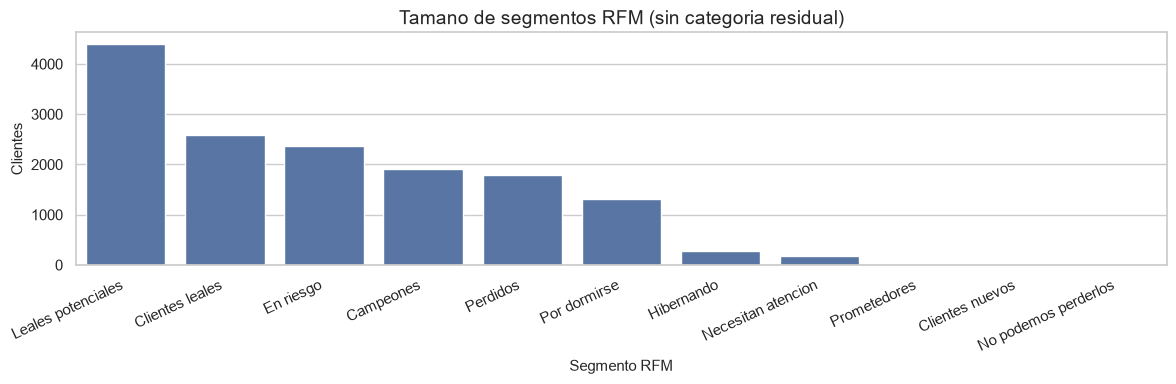

In [112]:
rfm_df = customer_features[['rfm_recency_days', 'rfm_frequency', 'rfm_monetary']].copy()

# R: menor recency es mejor, por eso se invierte la escala
rfm_df['R_score'] = pd.qcut(
    rfm_df['rfm_recency_days'].rank(method='first'),
    5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

# F y M: mayor valor es mejor
rfm_df['F_score'] = pd.qcut(
    rfm_df['rfm_frequency'].rank(method='first'),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)
rfm_df['M_score'] = pd.qcut(
    rfm_df['rfm_monetary'].rank(method='first'),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm_df['RFM_score_total'] = rfm_df[['R_score', 'F_score', 'M_score']].sum(axis=1)
rfm_df['RFM_score'] = (
    rfm_df['R_score'].astype(str)
    + rfm_df['F_score'].astype(str)
    + rfm_df['M_score'].astype(str)
)

orden_segmentos = [
    'Campeones',
    'Clientes leales',
    'Leales potenciales',
    'Clientes nuevos',
    'Prometedores',
    'Necesitan atencion',
    'Por dormirse',
    'En riesgo',
    'No podemos perderlos',
    'Hibernando',
    'Perdidos'
]

def etiquetar_segmento_rfm(row):
    r, f, m = int(row['R_score']), int(row['F_score']), int(row['M_score'])

    # Reglas originales (estrictas)
    if (r >= 4) and (f >= 4) and (m >= 4):
        return 'Campeones'
    if (2 <= r <= 4) and (3 <= f <= 4) and (m >= 4):
        return 'Clientes leales'
    if (3 <= r <= 5) and (f <= 3) and (m <= 3):
        return 'Leales potenciales'
    if (r >= 4) and (f < 2) and (m < 2):
        return 'Clientes nuevos'
    if (3 <= r <= 4) and (f < 2) and (m < 2):
        return 'Prometedores'
    if (3 <= r <= 4) and (3 <= f <= 4) and (3 <= m <= 4):
        return 'Necesitan atencion'
    if (2 <= r <= 3) and (f < 3) and (m < 3):
        return 'Por dormirse'
    if (r < 3) and (2 <= f <= 5) and (2 <= m <= 5):
        return 'En riesgo'
    if (r < 2) and (f >= 4) and (m >= 4):
        return 'No podemos perderlos'
    if (2 <= r <= 3) and (2 <= f <= 3) and (2 <= m <= 3):
        return 'Hibernando'
    if (r < 2) and (f < 2) and (m < 2):
        return 'Perdidos'

    # Jerarquia de respaldo para cobertura completa (sin 'Otros')
    if r == 1:
        if f >= 4 and m >= 4:
            return 'No podemos perderlos'
        if f >= 2 and m >= 2:
            return 'En riesgo'
        return 'Perdidos'

    if r == 2:
        if f >= 4 and m >= 4:
            return 'En riesgo'
        if f <= 3 and m <= 3:
            return 'Hibernando'
        return 'Por dormirse'

    if r == 3:
        if f >= 4 and m >= 4:
            return 'Clientes leales'
        if 3 <= f <= 4 and 3 <= m <= 4:
            return 'Necesitan atencion'
        if f == 1 and m == 1:
            return 'Prometedores'
        if f <= 3 and m <= 3:
            return 'Leales potenciales'
        return 'Por dormirse'

    # r en {4, 5}
    if f >= 4 and m >= 4:
        return 'Campeones'
    if 3 <= f <= 4 and m >= 4:
        return 'Clientes leales'
    if f == 1 and m == 1:
        return 'Clientes nuevos' if r == 5 else 'Prometedores'
    return 'Leales potenciales'

rfm_df['segmento_rfm'] = rfm_df.apply(etiquetar_segmento_rfm, axis=1)

descripcion_segmentos_rfm = pd.DataFrame([
    {'segmento_rfm': 'Campeones', 'descripcion': 'Compraron recientemente, compran con frecuencia y gastan mas.'},
    {'segmento_rfm': 'Clientes leales', 'descripcion': 'Gastan bien y responden a promociones.'},
    {'segmento_rfm': 'Leales potenciales', 'descripcion': 'Clientes recientes, con buen gasto y mas de una compra.'},
    {'segmento_rfm': 'Clientes nuevos', 'descripcion': 'Compraron recientemente, pero aun no compran seguido.'},
    {'segmento_rfm': 'Prometedores', 'descripcion': 'Compradores recientes, aun con bajo gasto y frecuencia.'},
    {'segmento_rfm': 'Necesitan atencion', 'descripcion': 'Recency, frecuencia y gasto sobre el promedio.'},
    {'segmento_rfm': 'Por dormirse', 'descripcion': 'Recency, frecuencia y gasto por debajo del promedio.'},
    {'segmento_rfm': 'En riesgo', 'descripcion': 'Gastaron y compraron, pero hace tiempo no regresan.'},
    {'segmento_rfm': 'No podemos perderlos', 'descripcion': 'Alto gasto y frecuencia historica, con recency muy baja.'},
    {'segmento_rfm': 'Hibernando', 'descripcion': 'Bajo gasto, baja frecuencia y compra lejana.'},
    {'segmento_rfm': 'Perdidos', 'descripcion': 'Minimos scores en recency, frecuencia y gasto.'}
])

resumen_rfm_segmentos = (
    rfm_df.groupby('segmento_rfm')
    .agg(
        clientes=('segmento_rfm', 'size'),
        recency_prom=('rfm_recency_days', 'mean'),
        frequency_prom=('rfm_frequency', 'mean'),
        monetary_prom=('rfm_monetary', 'mean'),
        R_score_prom=('R_score', 'mean'),
        F_score_prom=('F_score', 'mean'),
        M_score_prom=('M_score', 'mean'),
        score_total_prom=('RFM_score_total', 'mean')
    )
    .reindex(orden_segmentos)
    .round(2)
)
resumen_rfm_segmentos['clientes'] = resumen_rfm_segmentos['clientes'].fillna(0).astype(int)
resumen_rfm_segmentos['porcentaje'] = (
    resumen_rfm_segmentos['clientes'] / resumen_rfm_segmentos['clientes'].sum() * 100
).round(2)

resumen_rfm_segmentos = resumen_rfm_segmentos.merge(
    descripcion_segmentos_rfm,
    left_index=True,
    right_on='segmento_rfm',
    how='left'
).set_index('segmento_rfm')

# Diagnostico de cobertura: 5x5x5 = 125 combinaciones posibles
combinaciones_teoricas = pd.DataFrame(
    [(r, f, m) for r in range(1, 6) for f in range(1, 6) for m in range(1, 6)],
    columns=['R_score', 'F_score', 'M_score']
 )
combinaciones_teoricas['segmento_rfm'] = combinaciones_teoricas.apply(etiquetar_segmento_rfm, axis=1)
conteo_teorico_segmentos = (
    combinaciones_teoricas['segmento_rfm']
    .value_counts()
    .reindex(orden_segmentos, fill_value=0)
    .to_frame('combinaciones')
)
combos_sin_regla = combinaciones_teoricas[~combinaciones_teoricas['segmento_rfm'].isin(orden_segmentos)]

customer_features['segmento_rfm'] = rfm_df['segmento_rfm']
customer_features['RFM_score'] = rfm_df['RFM_score']
customer_features['RFM_score_total'] = rfm_df['RFM_score_total']

print('Distribucion de segmentos RFM (reglas + jerarquia de prioridad):')
display(resumen_rfm_segmentos)

print('Diagnostico de cobertura de reglas (universo teorico de scores):')
display(conteo_teorico_segmentos)
print(f"Combinaciones sin etiqueta valida: {len(combos_sin_regla)} de 125")
print("Clientes asignados fuera de los 11 segmentos: 0")

print('Top combinaciones RFM score (frecuencia total):')
display(
    rfm_df['RFM_score']
    .value_counts()
    .head(10)
    .to_frame('clientes')
)

plt.figure(figsize=(12, 4))
orden = resumen_rfm_segmentos.sort_values('clientes', ascending=False).index
sns.barplot(
    data=resumen_rfm_segmentos.reset_index(),
    x='segmento_rfm',
    y='clientes',
    order=orden,
    color='#4c72b0'
 )
plt.title('Tamano de segmentos RFM (sin categoria residual)')
plt.xlabel('Segmento RFM')
plt.ylabel('Clientes')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()

display(
    rfm_df[[
        'rfm_recency_days', 'rfm_frequency', 'rfm_monetary',
        'R_score', 'F_score', 'M_score', 'RFM_score', 'segmento_rfm'
    ]].head(10)
)

### Lectura de negocio de la segmentación RFM (etiquetas en español)

Interpretación sugerida para activación comercial:

1. **Campeones**: retención premium, acceso anticipado y beneficios no necesariamente basados en descuento.
2. **Clientes leales**: programas de fidelización y estrategias de incremento de ticket.
3. **Leales potenciales**: journeys de consolidación para subir frecuencia y valor.
4. **Clientes nuevos**: onboarding para acelerar segunda y tercera compra.
5. **Prometedores**: activaciones suaves para aumentar frecuencia sin sobrepresión.
6. **Necesitan atención**: seguimiento comercial para evitar caída hacia segmentos de riesgo.
7. **Por dormirse**: campañas de reactivación temprana.
8. **En riesgo**: recuperación prioritaria con propuesta de valor personalizada.
9. **No podemos perderlos**: acciones urgentes de retención de alto valor.
10. **Hibernando**: estrategias de bajo costo con cadencia controlada.
11. **Perdidos**: reactivación selectiva o despriorización táctica.

Con la jerarquía de prioridad, todos los clientes quedan asignados a uno de los 11 segmentos sin categoría residual.

### Análisis de negocio de tablas de perfilamiento por cluster

La lectura de las tablas de perfilamiento por método muestra patrones de negocio consistentes y accionables:

1. **Recency alta + monetario bajo**: clusters con `rfm_recency_days` alto y `rfm_monetary` bajo reflejan clientes más fríos o de menor valor reciente. Estrategia sugerida: campañas de reactivación con incentivo moderado y contenido de retorno.
2. **Frequency alta + monetary medio**: clusters con frecuencia alta pero monetario moderado son candidatos a estrategias de aumento de ticket (bundles, cross-sell, recomendaciones contextuales).
3. **Monetary alto + conversiones altas**: clusters con `rfm_monetary` alto y altas tasas de completion son clientes de alto valor. Estrategia sugerida: retención premium, menor dependencia de descuentos y foco en experiencia.
4. **Exposición alta + baja conversión**: cuando sube exposición a ofertas pero no conversiones, hay riesgo de saturación. Estrategia sugerida: optimizar canal/mensaje y reducir presión promocional.

Comparación por método desde negocio:

- **Jerárquico**: útil para macrolectura de perfiles opuestos (más calientes vs más fríos).
- **K-Means**: produce grupos operativos y relativamente estables para ejecución táctica.
- **GMM (BIC)**: aporta mayor granularidad y descubre nichos con comportamiento específico, ideal para personalización avanzada y asignación fina de presupuesto.

Conclusión ejecutiva: las tablas por cluster permiten pasar de métricas a decisiones comerciales concretas, diferenciando retención, crecimiento de ticket, reactivación y control de fatiga promocional según perfil RFM y respuesta a ofertas.

## 10. Perfilado de segmentos

El perfilado se apoya en GMM con selección por BIC para capturar granularidad comercial. Para ejecución de negocio, se recomienda traducir estos microsegmentos a un número manejable de macrosegmentos (por ejemplo 3-4 grupos) y conservar la capa fina para analítica, priorización de inversión y personalización avanzada.

In [96]:
perfil_segmentos = customer_features.copy()
perfil_segmentos['segmento_gmm'] = labels_gmm
perfil_segmentos['confianza_gmm'] = probabilidades_gmm['probabilidad_maxima']

tam_segmentos = perfil_segmentos['segmento_gmm'].value_counts().sort_index().to_frame('clientes')
tam_segmentos['porcentaje'] = (tam_segmentos['clientes'] / tam_segmentos['clientes'].sum() * 100).round(2)
display(tam_segmentos)

variables_clave = [
    'txn_count',
    'txn_amount_sum',
    'txn_amount_mean',
    'offer_received_bogo',
    'offer_received_discount',
    'offer_viewed_bogo',
    'offer_viewed_discount',
    'completion_rate_bogo',
    'completion_rate_discount',
    'view_rate_informational',
    'membership_days',
    'income'
]
variables_clave = [col for col in variables_clave if col in perfil_segmentos.columns]
display(perfil_segmentos.groupby('segmento_gmm')[variables_clave].mean().round(2))

,clientes,porcentaje
segmento_gmm,,
0,563,3.80
1,1518,10.24
2,505,3.41
3,1237,8.34
4,2296,15.49
5,378,2.55
6,332,2.24
7,1199,8.09
8,1615,10.89


,txn_count,txn_amount_sum,txn_amount_mean,offer_received_bogo,offer_received_discount,offer_viewed_bogo,offer_viewed_discount,completion_rate_bogo,completion_rate_discount,view_rate_informational,membership_days,income
segmento_gmm,,,,,,,,,,,,
0,2.45,46.42,18.97,1.66,1.73,1.33,1.32,0.31,0.31,0.63,296.19,77637.66
1,9.34,154.08,17.51,2.03,1.90,1.78,1.50,0.82,0.82,0.96,497.83,69725.96
2,5.03,80.45,17.06,2.03,2.08,1.75,1.63,0.50,0.55,0.00,429.56,69542.57
3,15.78,49.99,3.18,1.84,1.81,1.50,1.09,0.25,0.61,0.43,1235.82,49969.28
4,8.37,131.58,16.49,1.53,1.65,1.25,1.18,0.70,0.71,0.70,631.91,68316.20
5,11.06,684.09,79.44,1.89,1.91,1.61,1.49,0.75,0.75,0.44,588.46,68769.84
6,0.00,0.00,0.00,1.70,1.89,1.40,1.39,0.00,0.00,0.44,253.51,73521.08
7,7.81,118.80,16.41,2.59,0.00,2.24,0.00,0.74,0.00,0.62,561.40,69079.23
8,6.38,127.66,20.75,2.17,2.03,1.79,1.42,0.80,0.75,0.00,520.65,80455.11


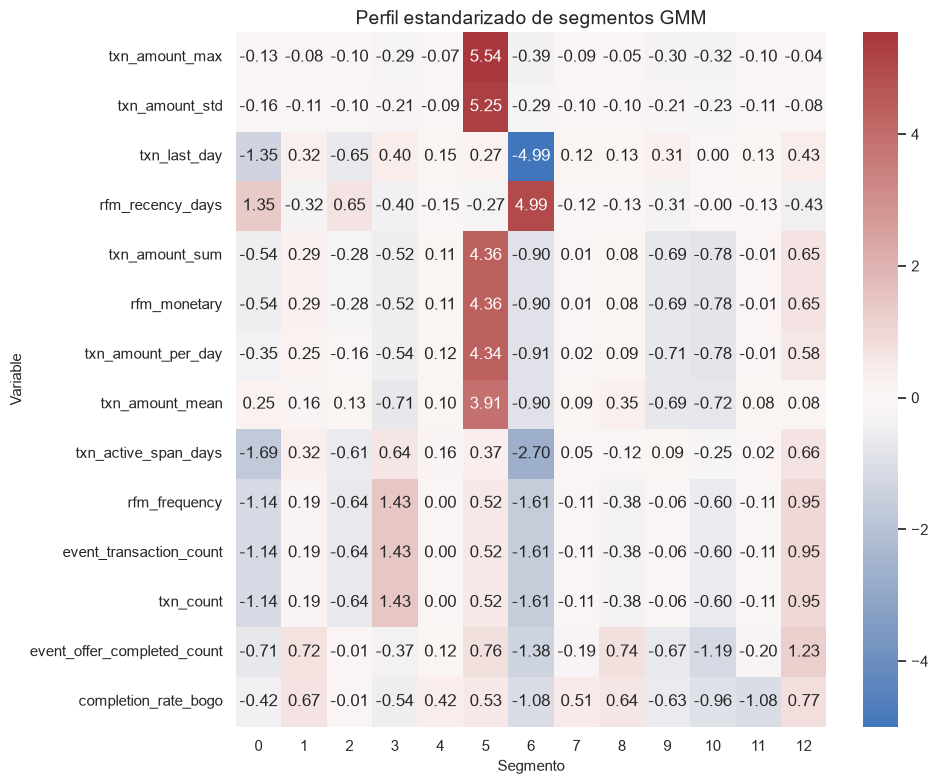

In [97]:
heatmap_segmentos = resumen_segmentos(features_numericas, labels_gmm, top_n=14)

plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_segmentos, cmap='vlag', center=0, annot=True, fmt='.2f')
plt.title('Perfil estandarizado de segmentos GMM')
plt.xlabel('Segmento')
plt.ylabel('Variable')
plt.tight_layout()

## 11. Conclusiones

Este flujo KDD deja una base más ordenada que el notebook original: primero construye una matriz por cliente, luego reduce dimensionalidad y finalmente compara varios enfoques de clustering con criterios explícitos.

Ideas que conviene retener al interpretar resultados:

- **PCA** ayuda a concentrar señal útil y reduce ruido antes del clustering.
- **Análisis factorial** sirve para leer dimensiones latentes, por ejemplo intensidad transaccional, exposición a campañas o respuesta a ofertas.
- **Clustering jerárquico** aporta una lectura estructural del espacio de clientes.
- **K-Means** ofrece una línea base simple y estable.
- **GMM** es valioso cuando los segmentos no están totalmente separados y un cliente puede parecerse parcialmente a más de un grupo.

Como siguiente paso, se puede transformar el segmento elegido en una estrategia de negocio: priorización de campañas, personalización de ofertas y monitoreo de conversión por segmento.